In [1]:
# Data Operations and Visualization Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Preprocessor Imports
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

# Hyperparameter Tuning Imports
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer, fbeta_score, precision_recall_curve

In [2]:
# Classifier Imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Evaluation Imports
from evaluation_metrics import get_evaluation_metrics

In [4]:
# Imports to build a pipeline for each model
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Model export and File Handling Imports
import joblib
import os
import sys

## Load Dataset, Analyze and Preprocess - EDA

In [5]:
# Define constants related to training dataset
TRAIN_DATASET_NAME = "train_data.csv"
TEST_DATASET_NAME = "test_data.csv"
DATASET_DIRECTORY = "../"
NOTEBOOK_FILE_LOC = os.getcwd()

In [6]:
# Read Data into a DataFrame
df_train = pd.read_csv(DATASET_DIRECTORY + TRAIN_DATASET_NAME)
df_test = pd.read_csv(DATASET_DIRECTORY + TEST_DATASET_NAME)

NUM_TRAIN_INSTANCES = len(df_train)
NUM_TEST_INSTANCES = len(df_test)

print("Number of training instances", NUM_TRAIN_INSTANCES)
print("Number of testing instances", NUM_TEST_INSTANCES)
df_train.head(10)

Number of training instances 4068
Number of testing instances 453


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,33,blue-collar,married,primary,no,50,yes,no,cellular,7,may,246,2,-1,0,unknown,no
1,46,entrepreneur,married,tertiary,no,2262,no,no,telephone,14,jul,44,14,-1,0,unknown,no
2,36,self-employed,married,tertiary,no,16430,yes,no,unknown,6,jun,197,3,-1,0,unknown,no
3,50,admin.,divorced,secondary,no,1111,yes,no,cellular,17,apr,50,1,-1,0,unknown,no
4,37,self-employed,married,secondary,no,215,yes,no,unknown,6,jun,61,1,-1,0,unknown,no
5,46,management,single,tertiary,no,2154,yes,no,cellular,21,jul,87,4,-1,0,unknown,no
6,60,admin.,married,secondary,no,2552,no,yes,cellular,30,jan,255,2,2,4,other,no
7,49,self-employed,married,secondary,no,2576,yes,no,cellular,15,may,64,6,-1,0,unknown,no
8,49,unemployed,married,tertiary,no,-471,yes,no,cellular,20,nov,77,3,185,7,failure,no
9,38,admin.,divorced,secondary,no,156,yes,no,unknown,17,jun,544,3,-1,0,unknown,no


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4068 non-null   int64 
 1   job        4068 non-null   object
 2   marital    4068 non-null   object
 3   education  4068 non-null   object
 4   default    4068 non-null   object
 5   balance    4068 non-null   int64 
 6   housing    4068 non-null   object
 7   loan       4068 non-null   object
 8   contact    4068 non-null   object
 9   day        4068 non-null   int64 
 10  month      4068 non-null   object
 11  duration   4068 non-null   int64 
 12  campaign   4068 non-null   int64 
 13  pdays      4068 non-null   int64 
 14  previous   4068 non-null   int64 
 15  poutcome   4068 non-null   object
 16  y          4068 non-null   object
dtypes: int64(7), object(10)
memory usage: 540.4+ KB


In [8]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000
mean,41.072517,1425.966077,15.993854,264.349558,2.796460,39.671829,0.538102
std,10.481142,3000.522397,8.261149,260.507172,3.097366,99.613918,1.638687
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,68.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,450.500000,16.000000,186.000000,2.000000,-1.000000,0.000000
75%,48.000000,1509.500000,21.000000,331.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,24.000000


In [9]:
# Check for duplicates and drop
# Note: de-duplication is applied only to the training set. The test set must
# be used completely/as-is for evaluation, so no rows are dropped from it.
print(f"Duplicates in train: {df_train.duplicated().sum()}")
df_train = df_train.drop_duplicates().reset_index(drop=True)

print(f"Duplicates in test (not dropped, test set is used as is): {df_test.duplicated().sum()}")

Duplicates in train: 0
Duplicates in test (not dropped, test set is used as is): 0


In [10]:
# Keep an untouched, raw snapshot of the data for building a deployable pipeline
df_train_raw = df_train.copy()

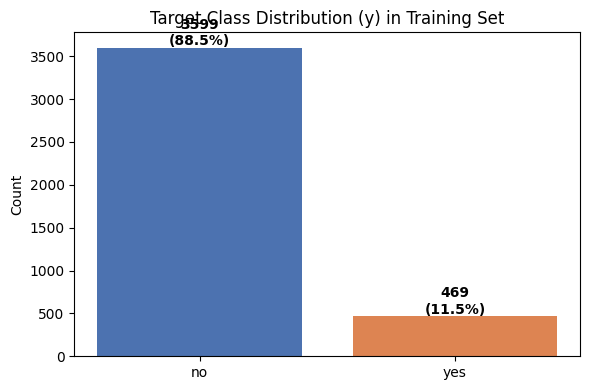

In [11]:
# Target Distribution
counts = df_train["y"].value_counts()
percentages = df_train["y"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
plt.title("Target Class Distribution (y) in Training Set")
plt.ylabel("Count")

for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
              f"{count}\n({pct:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

- The target is clearly skewed - more "no" data as compared to "yes", as a result recall and precision are going to be more important evaluation metrics as compared to accuracy.

In [12]:
# Handling values related to pdays
# pdays = -1 means not contacted yet, the model would perceive it as -1 days which is not possible.
# Applied identically to both train and test so the feature is defined the same way for both.
for df in (df_train, df_test):
    df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)
    df["pdays"] = df["pdays"].replace(-1, 0)

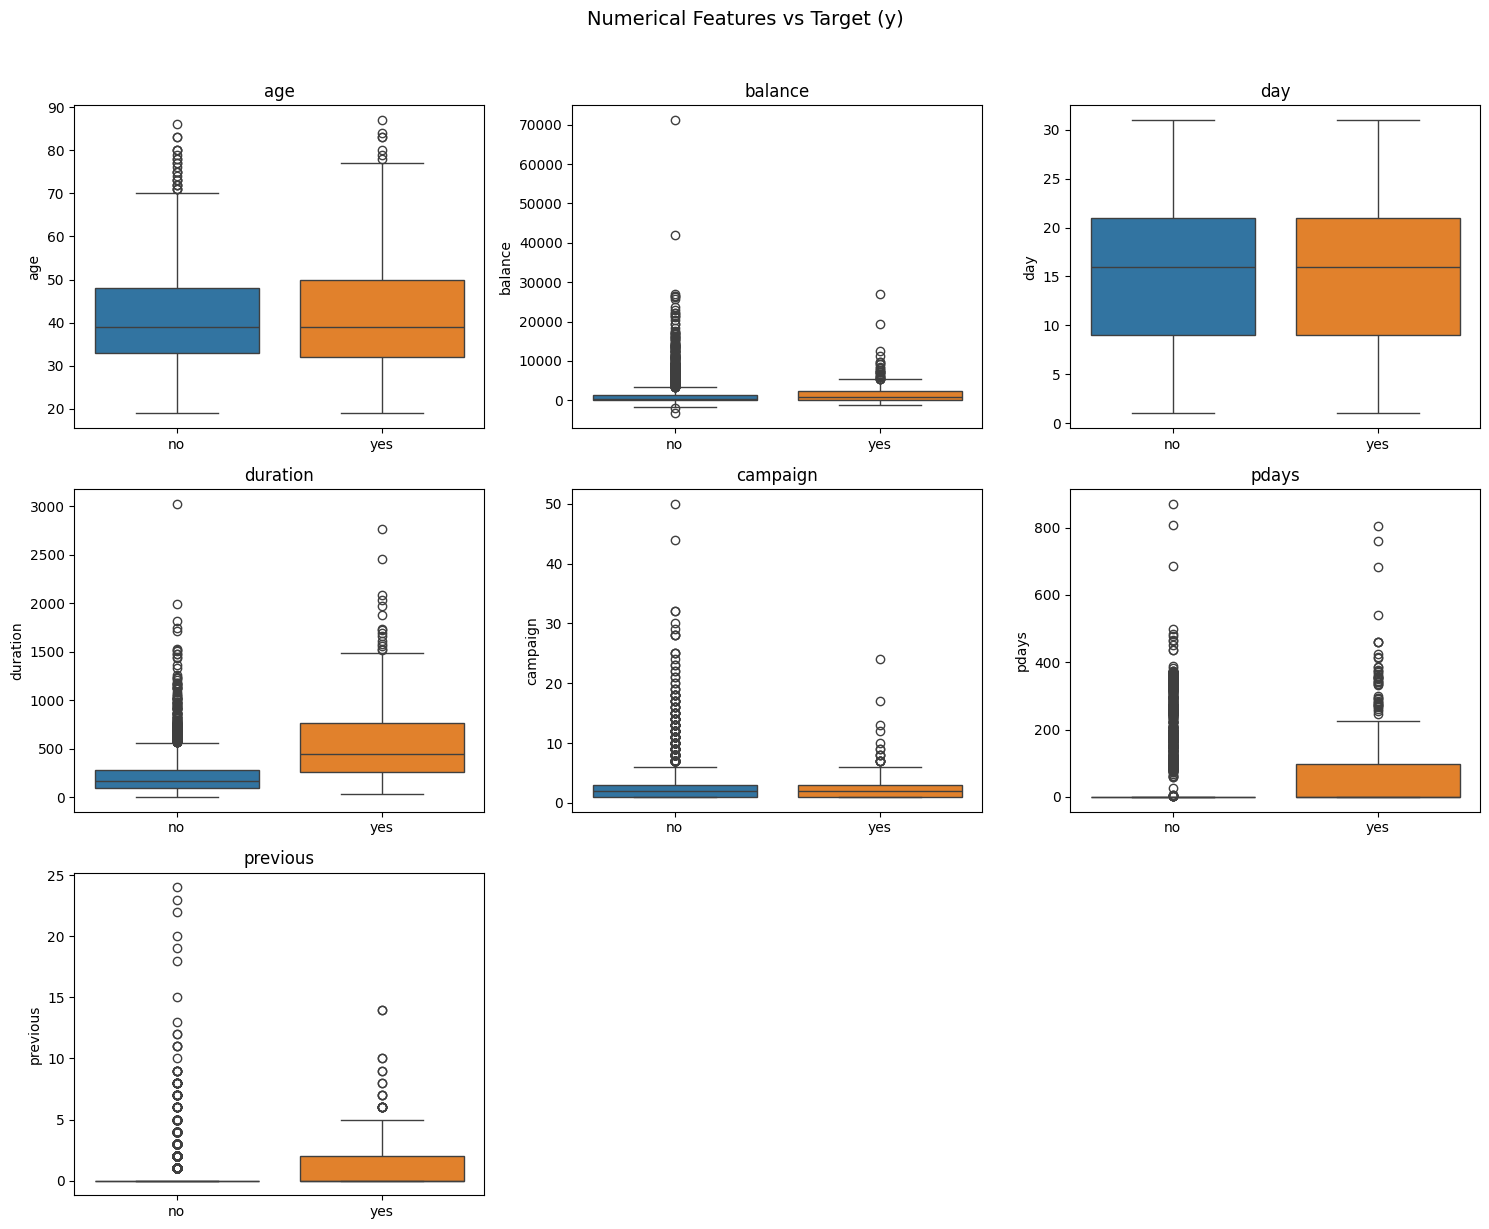

In [13]:
# Plotting a box plot to check relationship between numerical features and target
numerical_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_train, x="y", y=col, ax=axes[i], hue="y", legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Remove empty subplots if grid isn't perfectly filled
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numerical Features vs Target (y)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Strong signal 

- duration - clearest separation of the bunch. The "yes" (1) group has a noticeably higher median and wider spread than "no" (0). 

- pdays - "yes" group has a visibly higher median and box than "no."

- previous - similar story to pdays. "yes" group has a higher median and more prior contacts. Enforces that "has been contacted/converted before" is a meaningful pattern.

- campaign — mild inverse relationship. "no" group has a longer tail toward high values, suggesting repeated aggressive contact within the current campaign doesn't help conversion — possibly even correlates with annoyance/decline.

### Weak/No signal

- age, day, balance — medians and box ranges look nearly identical between "yes" and "no." 

- balance's outliers are visually dominating both groups (as before), but the actual box/median between yes/no looks similar.

In [14]:
# Transforming balance - Outliers have meaning in such a feature. Thus, performing a log transform to compress tails on both ends preserving data structure
# This is a stateless, row-wise transform (no statistics fit on the data), so it's safe to apply identically to both train and test.
for df in (df_train, df_test):
    df["balance"] = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

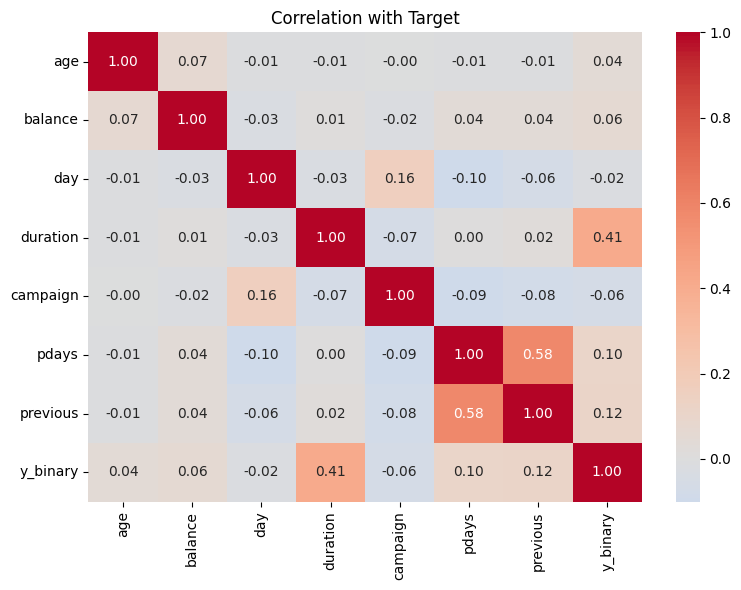

In [15]:
# Heatmap between numerical features and target
numerical_df_train = df_train[numerical_cols]


plt.figure(figsize=(8, 6))
df_train_corr = numerical_df_train.copy()
df_train_corr["y_binary"] = (df_train["y"] == "yes").astype(int)
sns.heatmap(df_train_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with Target")
plt.tight_layout()
plt.show()

- A strong relationship overserved between duration and target "y", indicating high predictive power. However, the duration of a call is known only after the call ends, thus any pre-call prediction might not suffice.
    - For this this specific reason, for each algorithm, we would be creating two models - one with duration intact and one without duration intact. 
- A high relationship observed between pdays and previous as well, but from business knowledge they're not redundant in information. A customer contacted 10 times over 2 years vs. 10 times last week are different in real signal, even if correlated in this dataset.


`Note: Since duration is to be dropped and kept as two different feature sets, the drop of the Duration column will be done post all pre-processing, when X/y are extracted from df_train and df_test.` 

In [16]:
# Day showed near-zero separation between zeros and ones
# Dropping day

df_train = df_train.drop(columns=["day"])
df_test = df_test.drop(columns=["day"])

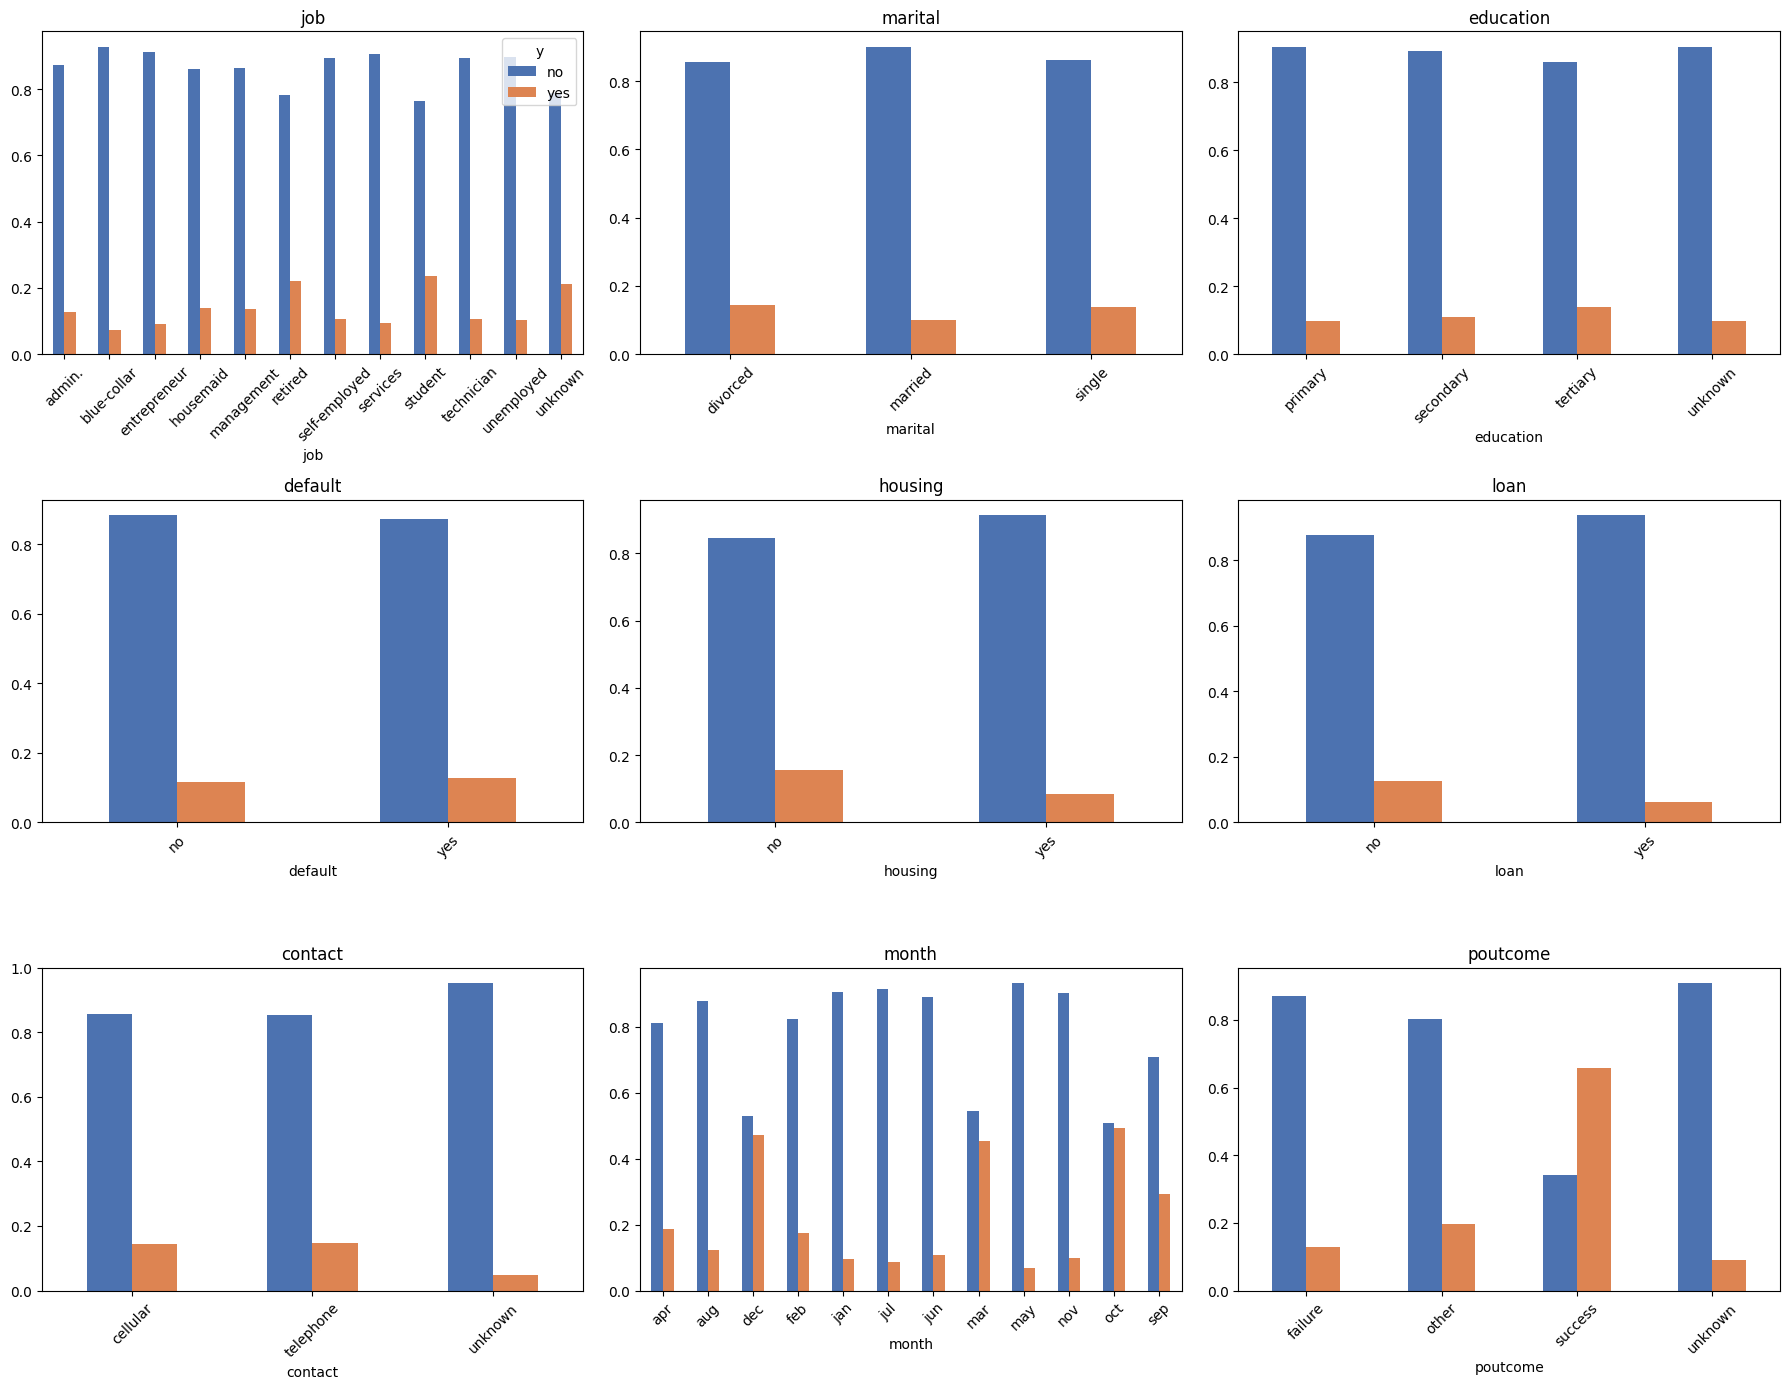

In [17]:
# Plotting a bar plot to check relationship between categorical features and target
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_train[col], df_train["y"], normalize="index")
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"], legend=(i==0))
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
# Drawing Cramer's-V to get numerical data for relationships between categorical features and target
def cramers_v(col, target):
    ct = pd.crosstab(col, target)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in categorical_cols:
    v = cramers_v(df_train[col], df_train["y"])
    print(f"{col}: {v:.4f}")

job: 0.1205
marital: 0.0632
education: 0.0519
default: 0.0018
housing: 0.1069
loan: 0.0699
contact: 0.1369
month: 0.2435
poutcome: 0.2941


### Analysis from Cramers-V - Relationship between Categorical Features and Target

| Feature   | Cramer's V | Verdict                                              |
|-----------|-----------:|------------------------------------------------------|
| poutcome  | 0.2941     | Strongest — keep                                     |
| month     | 0.2435     | Very strong — keep                                   |
| contact   | 0.1369     | Moderate — keep                                      |
| job       | 0.1205     | Moderate — keep                                      |
| housing   | 0.1069     | Moderate — keep                                      |
| loan      | 0.0699     | Weak-moderate — keep                                 |
| marital   | 0.0632     | Weak — keep, marginal                                |
| education | 0.0519     | Weak — keep, marginal                                |
| default   | 0.0018     | Essentially zero — dropped                           |

In [19]:
# Drop default as it has near 0 relationship with the target
df_train = df_train.drop(columns="default")
df_test = df_test.drop(columns="default")

In [20]:
# Encoding remaining categorical features

# Binary
for df in (df_train, df_test):
    for col in ["housing", "loan", "y"]:
        df[col] = df[col].map({"yes": 1, "no": 0})

# Ordinal
education_order = {"unknown": 0, "primary": 1, "secondary": 2, "tertiary": 3}
for df in (df_train, df_test):
    df["education"] = df["education"].map(education_order)

# Nominal (one-hot)
# The dummy columns (which categories get their own column, and in what order)
# are derived from the TRAINING set only. df_test is then reindexed onto that
# exact same column set: a category seen only at test time gets dropped
# (all-zero, same as the reference/dropped category), and any train-time
# dummy column absent from the test data is added back as all-zero. This
# keeps train and test encoded identically with no leakage from test into how
# the encoding is defined.
nominal_cols = ["job", "marital", "contact", "poutcome", "month"]

df_train = pd.get_dummies(df_train, columns=nominal_cols, drop_first=True)
onehot_cols = df_train.select_dtypes(include="bool").columns
df_train[onehot_cols] = df_train[onehot_cols].astype(int)

df_test = pd.get_dummies(df_test, columns=nominal_cols, drop_first=True)
test_onehot_cols = df_test.select_dtypes(include="bool").columns
df_test[test_onehot_cols] = df_test[test_onehot_cols].astype(int)

# Align df_test's columns (including one-hot columns) to df_train's exactly
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

In [21]:
print(f"Train - Data Modifications did not leave any null values: {df_train.isnull().sum().sum() == 0}")
print(f"Train - All categorical columns encoded: {df_train.select_dtypes(include='object').empty}")
print(f"Test - Data Modifications did not leave any null values: {df_test.isnull().sum().sum() == 0}")
print(f"Test - All categorical columns encoded: {df_test.select_dtypes(include='object').empty}")

Train - Data Modifications did not leave any null values: True
Train - All categorical columns encoded: True
Test - Data Modifications did not leave any null values: True
Test - All categorical columns encoded: True


In [22]:
# Extract features (X) and target (y) from the dataset

# X without duration (as per analysis from the confusion matrix)
X_train_without_duration = df_train.drop(columns=["y", "duration"])
X_test_without_duration = df_test.drop(columns=["y", "duration"])

# X with duration
X_train_with_duration = df_train.drop(columns=["y"])
X_test_with_duration = df_test.drop(columns=["y"])

# y - independent of duration drop
y_train = df_train["y"]
y_test = df_test["y"]

# Ensuring feature/target instance counts line up within each split
print(f"Number of training feature instances without duration: {len(X_train_without_duration)}")
print(f"Number of training feature instances with duration: {len(X_train_with_duration)}")
print(f"Number of training target instances: {len(y_train)}")

print(f"Number of testing feature instances without duration: {len(X_test_without_duration)}")
print(f"Number of testing feature instances with duration: {len(X_test_with_duration)}")
print(f"Number of testing target instances: {len(y_test)}")

Number of training feature instances without duration: 4068
Number of training feature instances with duration: 4068
Number of training target instances: 4068
Number of testing feature instances without duration: 453
Number of testing feature instances with duration: 453
Number of testing target instances: 453


## Train and Test Sets (Pre-Split)

In [23]:
# No train_test_split is performed. train_data.csv and test_data.csv are
# already separate, pre-split files: df_train is used exclusively to fit and
# tune every model below, and df_test is held out purely for final evaluation
# (each dataset is used in full, and the exact same preprocessing/feature
# engineering above has already been applied identically to both).
print(f"Training on {len(df_train)} instances, testing on {len(df_test)} instances")

Training on 4068 instances, testing on 453 instances


## Defining functions common to all models to be built

In [24]:
def build_model(lib_model_object, X_train, y_train, requires_scaling=True):
    '''
    """
    Fit a scikit-learn classifier on the training dataset with optional feature scaling.

    This unified utility handles independent data replication, optional feature 
    standardization via StandardScaler, and model training while preserving the 
    integrity of the original input datasets.

    Parameters
    ----------
    lib_model_object : estimator object
        An un-fitted scikit-learn compatible classifier instance or pipeline 
        implementing the `.fit()` method.
    X_train : {array-like, sparse matrix, DataFrame} of shape (n_samples, n_features)
        The training input samples representing the feature space.
    y_train : array-like of shape (n_samples,)
        The target values (class labels) representing the ground truth.
    requires_scaling : bool, default=True
        Flag to determine if feature standardization should be applied to `X_train`.
        If True, initializes and fits a `StandardScaler`.

    Returns
    -------
    model : estimator object
        The trained estimator instance fitted on the (optionally scaled) training data.
    scaler : StandardScaler or None
        The fitted `StandardScaler` instance containing the empirical mean and 
        variance computed from `X_train`. Returns `None` if `requires_scaling` is False.

    Notes
    -----
    - This function executes `.copy()` on both `X_train` and `y_train` to prevent 
      in-place data mutations and downstream side-effects on your working datasets.
    - Note: If `lib_model_object` is passed as a raw instance, scikit-learn's `.fit()` 
      will modify it in-place. Thus, ensure you pass a new instance of a model to 
      fit.
    '''
    # Make a copy of X_train and y_train so as to not disturb the original training dataset. 
    # Allows re-use of dataset
    X_train_copy = X_train.copy()
    y_train_copy = y_train.copy()

    # Performing scaling on X_train if required
    scaler = None
    if requires_scaling:
        scaler = StandardScaler()
        X_train_copy = scaler.fit_transform(X_train_copy)

    # Built the model 
    model = lib_model_object.fit(X_train_copy, y_train_copy)
    return model, scaler

In [25]:
def find_best_threshold_cv(lib_model_object, X_train, y_train, requires_scaling=True,
                            cv=5, beta=1.5, min_precision=0.2):
    """
    Selects a classification threshold using ONLY training data, via cross-validated
    out-of-fold probability predictions — the test set is never touched here, so the
    threshold is chosen the same way any other hyperparameter would be.

    Uses F-beta (beta=1.5 by default) to keep some recall priority given the class
    imbalance, without going as far as beta=1.5 — with a strong imbalance and a model
    whose scores aren't well separated, pure F2 optimization can degenerate to a
    near-zero threshold (i.e. "always predict yes"), since F2 mathematically rewards
    recall heavily enough that a tiny precision gain elsewhere can't outweigh any
    recall loss. `min_precision` guards against exactly this: candidate thresholds
    below that precision floor are excluded from consideration entirely, so the
    selected threshold can never collapse into a degenerate "ignore the negative
    class" solution.

    The reason a more recall-oriented threshold is chosen is because of:
    1. The class imbalance - More number of "no" target classes than "yes"
    2. Business - Recall is more precious than Precision (in other words,
        False Negatives are more costly)

    Parameters
    ----------
    beta : float, default=1.5
        Weight on recall relative to precision in the F-beta score. Higher values
        favor recall more aggressively; 1.0 is the balanced F1 score.
    min_precision : float, default=0.2
        Minimum precision a candidate threshold must achieve (on training-side CV
        predictions) to be eligible for selection. Prevents the search from picking
        a degenerate near-zero threshold that predicts the positive class for
        virtually everyone. Set to 0 to disable this floor.

    Returns
    -------
    float : the probability threshold selected under these constraints.
    """
    if requires_scaling:
        cv_estimator = Pipeline([
            ("scaler", StandardScaler()),
            ("model", clone(lib_model_object)),
        ])
    else:
        cv_estimator = clone(lib_model_object)

    oof_proba = cross_val_predict(
        cv_estimator, X_train, y_train, cv=cv, method="predict_proba"
    )[:, -1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
    precisions, recalls = precisions[:-1], recalls[:-1]  # drop the point with no threshold

    f_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)

    if min_precision > 0:
        meets_floor = precisions >= min_precision
        if meets_floor.any():
            f_scores = np.where(meets_floor, f_scores, -1)
        else:
            # No threshold clears the floor (rare, weak-model case) — fall back to
            # whichever threshold gets closest to it rather than silently ignoring
            # the constraint.
            return thresholds[np.argmax(precisions)]

    best_idx = np.argmax(f_scores)
    return thresholds[best_idx]


## Importing the Common Preprocessor to be used in Pipeline 

In [26]:
sys.path.append(str(NOTEBOOK_FILE_LOC))
from preprocessing import (
    clean_and_engineer, SafeEncoder, build_common_preprocessor,
    DROP_ALWAYS, BINARY_COLS, ORDINAL_COLS, EDUCATION_ORDER, NOMINAL_COLS,
)

## Pipeline Functions

In [27]:
def build_deployable_pipeline(classifier, scaler=None, with_duration: bool=True) -> Pipeline:
    """
    Assembles a single, self-contained Pipeline that takes RAW (unencoded) input
    and produces predictions end-to-end: cleaning -> encoding -> scaling -> model.
    `scaler`/`classifier` should be unfitted instances so this pipeline owns 
    independent fit state. 'scaler' to be set None if no scaling is to be performed.
    """
    if scaler is not None:
        return Pipeline([
            ("preprocessor", build_common_preprocessor(with_duration=with_duration)),
            ("scaler", clone(scaler)),
            ("classifier", clone(classifier)),
        ])
    
    return Pipeline([
        ("preprocessor", build_common_preprocessor(with_duration=with_duration)),
        ("classifier", clone(classifier)),
    ])

In [28]:
def save_deployable_model(pipeline: Pipeline, threshold: float, model_name: str,
                            with_duration: bool) -> str:
    """
    Persists a fitted deployable pipeline together with its tuned decision threshold
    in a single joblib file. Bundling both together means a downstream consumer can't 
    accidentally deploy the pipeline while silently reverting to the wrong threshold.

    The saved artifact is a dict: {"pipeline": ..., "threshold": ..., "metadata": ...}.
    Predicting downstream should always go through:
        proba = bundle["pipeline"].predict_proba(raw_df_train)[:, -1]
        pred  = (proba >= bundle["threshold"]).astype(int)
    rather than calling bundle["pipeline"].predict(raw_df_train) directly.
    """
    variant = "with_duration" if with_duration else "without_duration"
    output_dir = f"{NOTEBOOK_FILE_LOC}/pipelines/{variant}"
    os.makedirs(output_dir, exist_ok=True)

    bundle = {
        "pipeline": pipeline,
        "threshold": threshold,
        "metadata": {
            "model_name": model_name,
            "with_duration": with_duration,
            "positive_class": "yes",
            "negative_class": "no",
        },
    }

    file_loc = f"{output_dir}/{model_name}_pipeline.joblib"
    joblib.dump(bundle, file_loc)
    return file_loc

## Building Models based on pre-processed Dataset

- Each Model will be created twice - once with duration as a feature and another without
    - Reason, as stated above, is because there are cases where predictions have to be made pre-call which would not have the attribute duration yet. 
    - Duration, however, is an extremely strong predictor in whether marketing attempt passes or fails (yes or no)

### Logistic Regression

##### LR Model without Duration Feature

In [29]:
# Defining Model Instance
logistic_regression_without_duration = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

In [30]:
# Train model without duration
logistic_regression_classifier_without_duration, logistic_regression_scaler_without_duration = build_model(
    logistic_regression_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
logistic_regression_threshold_without_duration = find_best_threshold_cv(
    logistic_regression_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

logistic_regression_classifier_without_duration

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
# Scaling X_test with obtained scaler from the build process
logistic_regression_X_test_without_duration_scaled = logistic_regression_scaler_without_duration.transform(X_test_without_duration)

# Getting y_scores
logistic_regression_y_score_without_duration = logistic_regression_classifier_without_duration.predict_proba(logistic_regression_X_test_without_duration_scaled)[:, -1]

({'accuracy': np.float64(0.8013245033112583),
  'auc_score': 0.7526855937080376,
  'precision': np.float64(0.2840909090909091),
  'recall': np.float64(0.4807692307692308),
  'f1_score': np.float64(0.35714285714285715),
  'mcc': 0.260782114088365,
  'threshold': np.float64(0.5896097974271759)},
 <Figure size 400x300 with 1 Axes>)

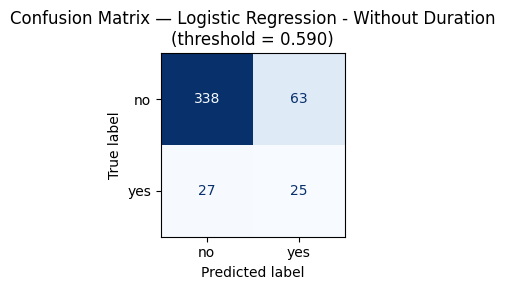

In [32]:
# Evaluation of Metrics
logistic_regression_evaluation_metrics_without_duration = get_evaluation_metrics(
    "Logistic Regression - Without Duration",
    y_test,
    logistic_regression_y_score_without_duration,
    threshold=logistic_regression_threshold_without_duration
)
logistic_regression_evaluation_metrics_without_duration[0], logistic_regression_evaluation_metrics_without_duration[2]

In [33]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_without_duration = df_train_raw.loc[X_train_without_duration.index].drop(columns=["y", "duration"], errors="ignore")

logistic_regression_pipeline_without_duration = build_deployable_pipeline(
    scaler=logistic_regression_scaler_without_duration,
    classifier=logistic_regression_classifier_without_duration,
    with_duration=False,
)
logistic_regression_pipeline_without_duration.fit(X_train_raw_without_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=logistic_regression_pipeline_without_duration,
    threshold=logistic_regression_threshold_without_duration,
    model_name="logistic_regression",
    with_duration=False
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/without_duration/logistic_regression_pipeline.joblib


##### LR Model with Duration Feature

In [34]:
# Defining Model Instance
logistic_regression_with_duration = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

In [35]:
# Train model without duration
logistic_regression_classifier_with_duration, logistic_regression_scaler_with_duration = build_model(
    logistic_regression_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
logistic_regression_threshold_with_duration = find_best_threshold_cv(
    logistic_regression_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

logistic_regression_classifier_with_duration

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
# Scaling X_test with obtained scaler from the build process
logistic_regression_X_test_with_duration_scaled = logistic_regression_scaler_with_duration.transform(X_test_with_duration)

# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
logistic_regression_y_score_with_duration = logistic_regression_classifier_with_duration.predict_proba(logistic_regression_X_test_with_duration_scaled)[:, -1]

({'accuracy': np.float64(0.8211920529801324),
  'auc_score': 0.8667274122386341,
  'precision': np.float64(0.3592233009708738),
  'recall': np.float64(0.7115384615384616),
  'f1_score': np.float64(0.47741935483870973),
  'mcc': 0.4159765004655083,
  'threshold': np.float64(0.5264508118309955)},
 <Figure size 400x300 with 1 Axes>)

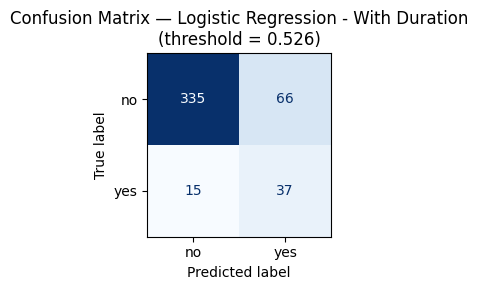

In [37]:
# Evaluation of Metrics
logistic_regression_evaluation_metrics_with_duration = get_evaluation_metrics(
    "Logistic Regression - With Duration",
    y_test,
    logistic_regression_y_score_with_duration,
    threshold=logistic_regression_threshold_with_duration
)
logistic_regression_evaluation_metrics_with_duration[0], logistic_regression_evaluation_metrics_with_duration[2]

In [38]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_with_duration = df_train_raw.loc[X_train_with_duration.index].drop(columns=["y"], errors="ignore")

logistic_regression_pipeline_with_duration = build_deployable_pipeline(
    scaler=logistic_regression_scaler_with_duration,
    classifier=logistic_regression_classifier_with_duration,
    with_duration=True,
)
logistic_regression_pipeline_with_duration.fit(X_train_raw_with_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=logistic_regression_pipeline_with_duration,
    threshold=logistic_regression_threshold_with_duration,
    model_name="logistic_regression",
    with_duration=True
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/with_duration/logistic_regression_pipeline.joblib


### K-Nearest Neighbors Classifier

In [39]:
# Hyper-Parameter Tuning - Using the Elbow Method to find the better value for k in KNN
def get_best_k_by_elbow_method(dataset: str, X_train, y_train, tolerance=0.05):
    possible_k_values = range(1, 52)
    scores = []

    f2_scorer = make_scorer(fbeta_score, beta=1.5)    # F2-Scores : A varaint of F1-scores that prioritizes recall (as is the usecase in this domain)

    for k in possible_k_values:
        # Scaling is fit INSIDE the pipeline, so cross_val_score fits it fresh on
        # each fold's training split only. Fitting a single StandardScaler on all
        # of X_train before the CV loop (the previous approach) leaks each fold's
        # held-out data into the scaling statistics used to score it.
        knn_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance")),
        ])
        cv_scores = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring=f2_scorer)
        scores.append(cv_scores.mean())

    plt.plot(possible_k_values, scores, marker="o")
    plt.xlabel("k")
    plt.ylabel("Cross-validated Scores")
    plt.title(f"F2 Scores vs k - {dataset}")
    plt.show()

    scores_arr = np.array(scores)
    best_score = scores_arr.max()
    threshold = best_score * (1 - tolerance)
    candidates = [k for k, s in zip(possible_k_values, scores) if s >= threshold]
    best_k = max(candidates)

    return best_k + 1 if best_k % 2 == 0 else best_k

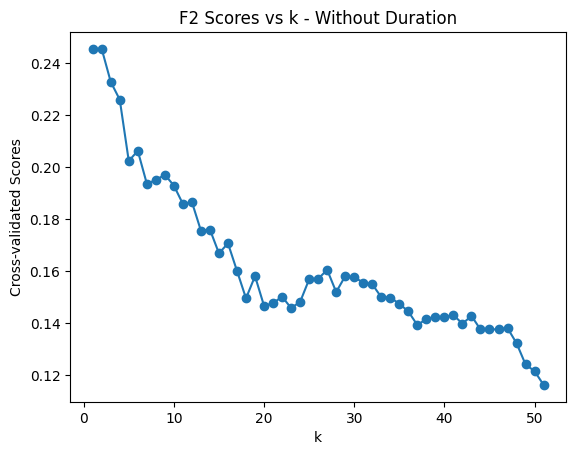


The best value for k for dataset without duration = 3


In [40]:
# Get best values of k for dataset without duration
knn_best_k_without_duration = get_best_k_by_elbow_method(
    "Without Duration",
    X_train_without_duration,
    y_train
)

print(f"\nThe best value for k for dataset without duration = {knn_best_k_without_duration}")

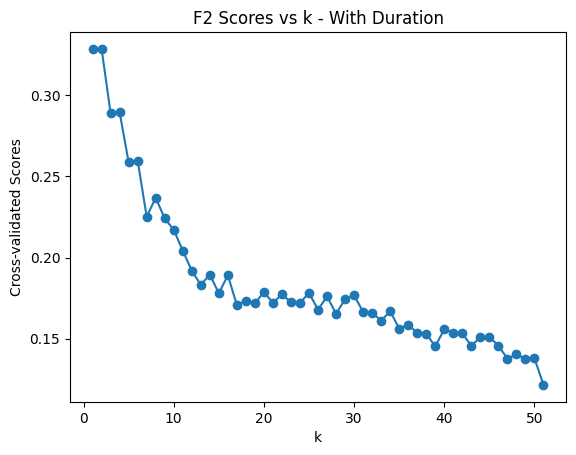


The best value for k for dataset with duration = 3


In [41]:
# Get best values of k for dataset with duration
knn_best_k_with_duration = get_best_k_by_elbow_method(
    "With Duration",
    X_train_with_duration,
    y_train
)

print(f"\nThe best value for k for dataset with duration = {knn_best_k_with_duration}")

##### KNN Model without Duration Feature

In [42]:
knn_without_duration = KNeighborsClassifier(n_neighbors=knn_best_k_without_duration, weights="distance")

In [43]:
knn_classifier_without_duration, knn_scaler_without_duration = build_model(
    knn_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
knn_threshold_without_duration = find_best_threshold_cv(
    knn_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

knn_classifier_without_duration

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
# Scaling X_test with obtained scaler from the build process
knn_X_test_without_duration_scaled = knn_scaler_without_duration.transform(X_test_without_duration)

# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
knn_y_score_without_duration = knn_classifier_without_duration.predict_proba(knn_X_test_without_duration_scaled)[:, -1]

({'accuracy': np.float64(0.7373068432671082),
  'auc_score': 0.5917657778630346,
  'precision': np.float64(0.18095238095238095),
  'recall': np.float64(0.36538461538461536),
  'f1_score': np.float64(0.24203821656050958),
  'mcc': 0.11400886267508042,
  'threshold': np.float64(0.2391296987449219)},
 <Figure size 400x300 with 1 Axes>)

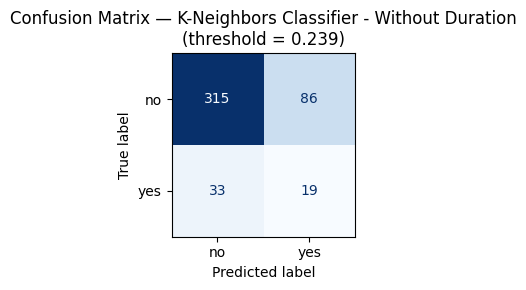

In [45]:
# Evaluation of Metrics
knn_evaluation_metrics_without_duration = get_evaluation_metrics(
    "K-Neighbors Classifier - Without Duration",
    y_test,
    knn_y_score_without_duration,
    threshold=knn_threshold_without_duration
)
knn_evaluation_metrics_without_duration[0], knn_evaluation_metrics_without_duration[2]

In [46]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_without_duration = df_train_raw.loc[X_train_without_duration.index].drop(columns=["y", "duration"], errors="ignore")

knn_pipeline_without_duration = build_deployable_pipeline(
    scaler=knn_scaler_without_duration,
    classifier=knn_classifier_without_duration,
    with_duration=False,
)
knn_pipeline_without_duration.fit(X_train_raw_without_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=knn_pipeline_without_duration,
    threshold=knn_threshold_without_duration,
    model_name="knn",
    with_duration=False
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/without_duration/knn_pipeline.joblib


##### KNN Model with Duration Feature

In [47]:
knn_with_duration = KNeighborsClassifier(n_neighbors=knn_best_k_with_duration, weights="distance")

In [48]:
knn_classifier_with_duration, knn_scaler_with_duration = build_model(
    knn_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
knn_threshold_with_duration = find_best_threshold_cv(
    knn_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

knn_classifier_with_duration

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
# Scaling X_test with obtained scaler from the build process
knn_X_test_with_duration_scaled = knn_scaler_with_duration.transform(X_test_with_duration)

# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
knn_y_score_with_duration = knn_classifier_with_duration.predict_proba(knn_X_test_with_duration_scaled)[:, -1]

({'accuracy': np.float64(0.8123620309050773),
  'auc_score': 0.6948494149242278,
  'precision': np.float64(0.3058823529411765),
  'recall': np.float64(0.5),
  'f1_score': np.float64(0.3795620437956205),
  'mcc': 0.28810616606364453,
  'threshold': np.float64(0.20202446124772572)},
 <Figure size 400x300 with 1 Axes>)

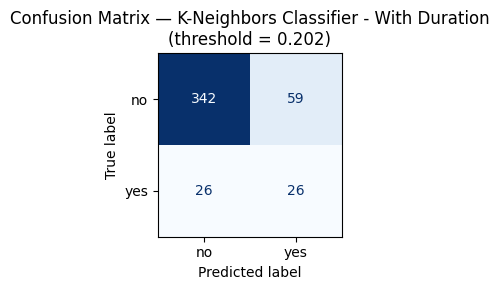

In [50]:
# Evaluation of Metrics
knn_evaluation_metrics_with_duration = get_evaluation_metrics(
    "K-Neighbors Classifier - With Duration",
    y_test,
    knn_y_score_with_duration,
    threshold=knn_threshold_with_duration
)
knn_evaluation_metrics_with_duration[0], knn_evaluation_metrics_with_duration[2]

In [51]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_with_duration = df_train_raw.loc[X_train_with_duration.index].drop(columns=["y"], errors="ignore")

knn_pipeline_with_duration = build_deployable_pipeline(
    scaler=knn_scaler_with_duration,
    classifier=knn_classifier_with_duration,
    with_duration=True,
)
knn_pipeline_with_duration.fit(X_train_raw_with_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=knn_pipeline_with_duration,
    threshold=knn_threshold_with_duration,
    model_name="knn",
    with_duration=True
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/with_duration/knn_pipeline.joblib


### Gaussian Naive Bayes Classifier

#### Gaussian NB Model without Duration Feature

In [52]:
gnb_without_duration = GaussianNB(priors=[0.5, 0.5])

In [53]:
gnb_classifier_without_duration, gnb_scaler_without_duration = build_model(
    gnb_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
gnb_threshold_without_duration = find_best_threshold_cv(
    gnb_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=True
)

gnb_classifier_without_duration

,priors,"[0.5, 0.5]"
,var_smoothing,1e-09


In [54]:
# Scaling X_test with obtained scaler from the build process
gnb_X_test_without_duration_scaled = gnb_scaler_without_duration.transform(X_test_without_duration)

# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
gnb_y_score_without_duration = gnb_classifier_without_duration.predict_proba(gnb_X_test_without_duration_scaled)[:, -1]

({'accuracy': np.float64(0.7726269315673289),
  'auc_score': 0.7107951275657012,
  'precision': np.float64(0.2616822429906542),
  'recall': np.float64(0.5384615384615384),
  'f1_score': np.float64(0.3522012578616352),
  'mcc': 0.25625727125629133,
  'threshold': np.float64(0.13336421752718736)},
 <Figure size 400x300 with 1 Axes>)

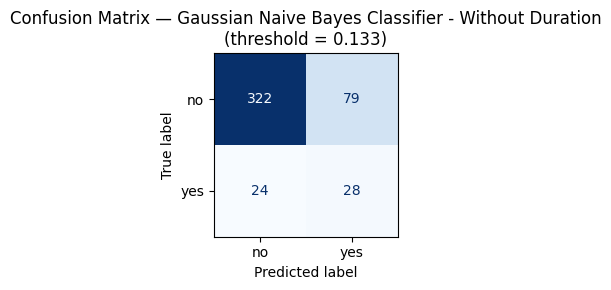

In [55]:
# Evaluation of Metrics
gnb_evaluation_metrics_without_duration = get_evaluation_metrics(
    "Gaussian Naive Bayes Classifier - Without Duration",
    y_test,
    gnb_y_score_without_duration,
    threshold=gnb_threshold_without_duration
)
gnb_evaluation_metrics_without_duration[0], gnb_evaluation_metrics_without_duration[2]

In [56]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_without_duration = df_train_raw.loc[X_train_without_duration.index].drop(columns=["y", "duration"], errors="ignore")

gnb_pipeline_without_duration = build_deployable_pipeline(
    scaler=gnb_scaler_without_duration,
    classifier=gnb_classifier_without_duration,
    with_duration=False,
)
gnb_pipeline_without_duration.fit(X_train_raw_without_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=gnb_pipeline_without_duration,
    threshold=gnb_threshold_without_duration,
    model_name="gnb",
    with_duration=False
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/without_duration/gnb_pipeline.joblib


#### Gaussian NB Model with Duration Feature

In [57]:
gnb_with_duration = GaussianNB(priors=[0.5, 0.5]) 

In [58]:
gnb_classifier_with_duration, gnb_scaler_with_duration = build_model(
    gnb_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
gnb_threshold_with_duration = find_best_threshold_cv(
    gnb_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=True
)

gnb_classifier_with_duration

,priors,"[0.5, 0.5]"
,var_smoothing,1e-09


In [59]:
# Scaling X_test with obtained scaler from the build process
gnb_X_test_with_duration_scaled = gnb_scaler_with_duration.transform(X_test_with_duration)

# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
gnb_y_score_with_duration = gnb_classifier_with_duration.predict_proba(gnb_X_test_with_duration_scaled)[:, -1]

({'accuracy': np.float64(0.7858719646799117),
  'auc_score': 0.7658497985804719,
  'precision': np.float64(0.2815533980582524),
  'recall': np.float64(0.5576923076923077),
  'f1_score': np.float64(0.3741935483870968),
  'mcc': 0.2837977334609487,
  'threshold': np.float64(0.21516592860005296)},
 <Figure size 400x300 with 1 Axes>)

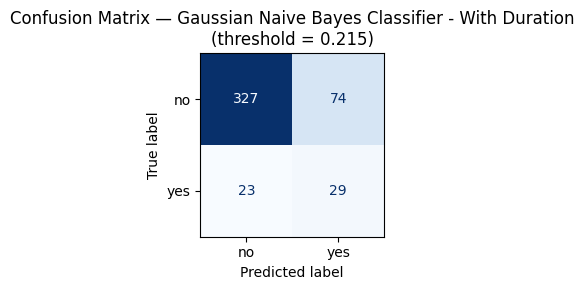

In [60]:
# Evaluation of Metrics
gnb_evaluation_metrics_with_duration = get_evaluation_metrics(
    "Gaussian Naive Bayes Classifier - With Duration",
    y_test,
    gnb_y_score_with_duration,
    threshold=gnb_threshold_with_duration
)
gnb_evaluation_metrics_with_duration[0], gnb_evaluation_metrics_with_duration[2]

In [61]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_with_duration = df_train_raw.loc[X_train_with_duration.index].drop(columns=["y"], errors="ignore")

gnb_pipeline_with_duration = build_deployable_pipeline(
    scaler=gnb_scaler_with_duration,
    classifier=gnb_classifier_with_duration,
    with_duration=True,
)
gnb_pipeline_with_duration.fit(X_train_raw_with_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=gnb_pipeline_with_duration,
    threshold=gnb_threshold_with_duration,
    model_name="gnb",
    with_duration=True
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/with_duration/gnb_pipeline.joblib


### Decision Tree Classifier

#### Decision Tree Model without Duration Feature

In [62]:
dt_without_duration = DecisionTreeClassifier(class_weight="balanced", random_state=42)

In [63]:
dt_classifier_without_duration, _ = build_model(
    dt_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=False
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
dt_threshold_without_duration = find_best_threshold_cv(
    dt_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=False
)

dt_classifier_without_duration

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [64]:
# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
dt_y_score_without_duration = dt_classifier_without_duration.predict_proba(X_test_without_duration)[:, -1]

({'accuracy': np.float64(0.8145695364238411),
  'auc_score': 0.5856272779589488,
  'precision': np.float64(0.24193548387096775),
  'recall': np.float64(0.28846153846153844),
  'f1_score': np.float64(0.2631578947368421),
  'mcc': 0.1588297193905688,
  'threshold': np.float64(1.0)},
 <Figure size 400x300 with 1 Axes>)

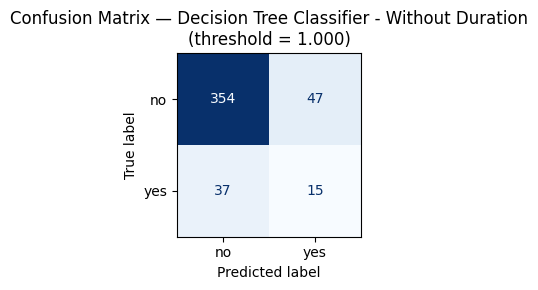

In [65]:
# Evaluation of Metrics
dt_evaluation_metrics_without_duration = get_evaluation_metrics(
    "Decision Tree Classifier - Without Duration",
    y_test,
    dt_y_score_without_duration,
    threshold=dt_threshold_without_duration
)
dt_evaluation_metrics_without_duration[0], dt_evaluation_metrics_without_duration[2]

In [66]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_without_duration = df_train_raw.loc[X_train_without_duration.index].drop(columns=["y", "duration"], errors="ignore")

dt_pipeline_without_duration = build_deployable_pipeline(
    classifier=dt_classifier_without_duration,
    with_duration=False,
)
dt_pipeline_without_duration.fit(X_train_raw_without_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=dt_pipeline_without_duration,
    threshold=dt_threshold_without_duration,
    model_name="dt",
    with_duration=False
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/without_duration/dt_pipeline.joblib


#### Decision Tree Model with Duration Feature

In [67]:
dt_with_duration = DecisionTreeClassifier(class_weight="balanced", random_state=42)

In [68]:
dt_classifier_with_duration, _ = build_model(
    dt_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=False
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
dt_threshold_with_duration = find_best_threshold_cv(
    dt_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=False
)

dt_classifier_with_duration

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [69]:
# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
dt_y_score_with_duration = dt_classifier_with_duration.predict_proba(X_test_with_duration)[:, -1]

({'accuracy': np.float64(0.8587196467991169),
  'auc_score': 0.6440389411087666,
  'precision': np.float64(0.38),
  'recall': np.float64(0.36538461538461536),
  'f1_score': np.float64(0.37254901960784315),
  'mcc': 0.29305305192019077,
  'threshold': np.float64(1.0)},
 <Figure size 400x300 with 1 Axes>)

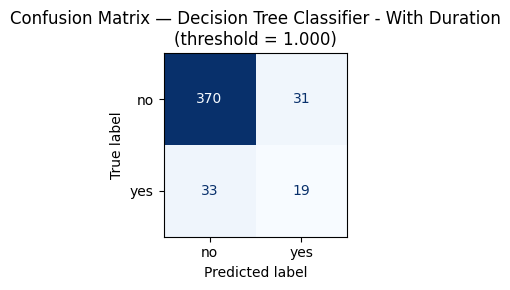

In [70]:
# Evaluation of Metrics
dt_evaluation_metrics_with_duration = get_evaluation_metrics(
    "Decision Tree Classifier - With Duration",
    y_test,
    dt_y_score_with_duration,
    threshold=dt_threshold_with_duration
)
dt_evaluation_metrics_with_duration[0], dt_evaluation_metrics_with_duration[2]

In [71]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_with_duration = df_train_raw.loc[X_train_with_duration.index].drop(columns=["y"], errors="ignore")

dt_pipeline_with_duration = build_deployable_pipeline(
    classifier=dt_classifier_with_duration,
    with_duration=True,
)
dt_pipeline_with_duration.fit(X_train_raw_with_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=dt_pipeline_with_duration,
    threshold=dt_threshold_with_duration,
    model_name="dt",
    with_duration=True
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/with_duration/dt_pipeline.joblib


### Random Forest Classifier

#### Random Forest Model without Duration Feature

In [72]:
rf_without_duration = RandomForestClassifier(class_weight="balanced", random_state=42)

In [73]:
rf_classifier_without_duration, _ = build_model(
    rf_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=False
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
rf_threshold_without_duration = find_best_threshold_cv(
    rf_without_duration,
    X_train_without_duration,
    y_train,
    requires_scaling=False
)

rf_classifier_without_duration

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
rf_y_score_without_duration = rf_classifier_without_duration.predict_proba(X_test_without_duration)[:, -1]

({'accuracy': np.float64(0.7439293598233996),
  'auc_score': 0.7526855937080376,
  'precision': np.float64(0.24193548387096775),
  'recall': np.float64(0.5769230769230769),
  'f1_score': np.float64(0.3409090909090909),
  'mcc': 0.24487091055862234,
  'threshold': np.float64(0.15)},
 <Figure size 400x300 with 1 Axes>)

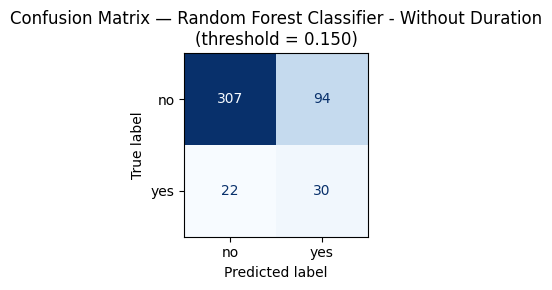

In [75]:
# Evaluation of Metrics
rf_evaluation_metrics_without_duration = get_evaluation_metrics(
    "Random Forest Classifier - Without Duration",
    y_test,
    rf_y_score_without_duration,
    threshold=rf_threshold_without_duration
)
rf_evaluation_metrics_without_duration[0], rf_evaluation_metrics_without_duration[2]

In [76]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_without_duration = df_train_raw.loc[X_train_without_duration.index].drop(columns=["y", "duration"], errors="ignore")

rf_pipeline_without_duration = build_deployable_pipeline(
    classifier=rf_classifier_without_duration,
    with_duration=False,
)
rf_pipeline_without_duration.fit(X_train_raw_without_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=rf_pipeline_without_duration,
    threshold=rf_threshold_without_duration,
    model_name="rf",
    with_duration=False
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/without_duration/rf_pipeline.joblib


#### Random Forest Model with Duration Feature

In [77]:
rf_with_duration = RandomForestClassifier(class_weight="balanced", random_state=42)

In [78]:
rf_classifier_with_duration, _ = build_model(
    rf_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=False
)

# Select a classification threshold using ONLY training data (via out-of-fold
# CV probabilities), so the test set stays untouched until final evaluation.
rf_threshold_with_duration = find_best_threshold_cv(
    rf_with_duration,
    X_train_with_duration,
    y_train,
    requires_scaling=False
)

rf_classifier_with_duration

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
# Getting y_scores; y_pred is now derived inside get_evaluation_metrics using
# the training-side tuned threshold rather than sklearn's hardcoded 0.5 default.
rf_y_score_with_duration = rf_classifier_with_duration.predict_proba(X_test_with_duration)[:, -1]

({'accuracy': np.float64(0.8388520971302428),
  'auc_score': 0.8833445233071168,
  'precision': np.float64(0.3939393939393939),
  'recall': np.float64(0.75),
  'f1_score': np.float64(0.5165562913907283),
  'mcc': 0.46310188953378306,
  'threshold': np.float64(0.2)},
 <Figure size 400x300 with 1 Axes>)

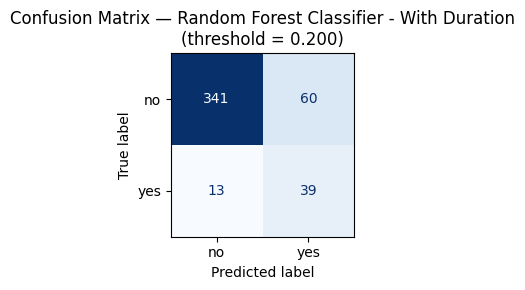

In [80]:
# Evaluation of Metrics
rf_evaluation_metrics_with_duration = get_evaluation_metrics(
    "Random Forest Classifier - With Duration",
    y_test,
    rf_y_score_with_duration,
    threshold=rf_threshold_with_duration
)
rf_evaluation_metrics_with_duration[0], rf_evaluation_metrics_with_duration[2]

In [81]:
# End-to-end deployable pipeline: raw input -> prediction.
X_train_raw_with_duration = df_train_raw.loc[X_train_with_duration.index].drop(columns=["y"], errors="ignore")

rf_pipeline_with_duration = build_deployable_pipeline(
    classifier=rf_classifier_with_duration,
    with_duration=True,
)
rf_pipeline_with_duration.fit(X_train_raw_with_duration, y_train)

saved_loc = save_deployable_model(
    pipeline=rf_pipeline_with_duration,
    threshold=rf_threshold_with_duration,
    model_name="rf",
    with_duration=True
)
print(f"Saved to {saved_loc}")

Saved to c:\Users\LENOVO\OneDrive\Documents\Study\AI_ML\ML\BITS\Assignment-2\bank-subscriptions-predictor\model/pipelines/with_duration/rf_pipeline.joblib


## Classification Thresholds

In [82]:
thresholds_used = {
    "Logistic Regression - Without Duration": logistic_regression_threshold_without_duration,
    "Logistic Regression - With Duration": logistic_regression_threshold_with_duration,
    "KNN - Without Duration": knn_threshold_without_duration,
    "KNN - With Duration": knn_threshold_with_duration,
    "Gaussian NB - Without Duration": gnb_threshold_without_duration,
    "Gaussian NB - With Duration": gnb_threshold_with_duration,
    "Decision Tree - Without Duration": dt_threshold_without_duration,
    "Decision Tree - With Duration": dt_threshold_with_duration,
    "Random Forest - Without Duration": rf_threshold_without_duration,
    "Random Forest - With Duration": rf_threshold_with_duration,
}

pd.Series(thresholds_used, name="selected_threshold").to_frame()

,selected_threshold
Logistic Regression - Without Duration,0.589610
Logistic Regression - With Duration,0.526451
KNN - Without Duration,0.239130
KNN - With Duration,0.202024
Gaussian NB - Without Duration,0.133364
Gaussian NB - With Duration,0.215166
Decision Tree - Without Duration,1.000000
Decision Tree - With Duration,1.000000
Random Forest - Without Duration,0.150000
Random Forest - With Duration,0.200000


### Collating the Metrics of Each Model - Each for with duration and without duration

In [83]:
# With duration

collated_metrics_with_duration = {
    "Logistic Regression Classifier": logistic_regression_evaluation_metrics_with_duration[0],
    "K-Nearest Neighbors Classifier": knn_evaluation_metrics_with_duration[0],
    "Gaussian Naive Bayes Classifier": gnb_evaluation_metrics_with_duration[0],
    "Decision Tree Classifier": dt_evaluation_metrics_with_duration[0],
    "Random Forest Classifier": rf_evaluation_metrics_with_duration[0] 
}

print("--------- Evaluation Metrics of Dataset with Duration ---------")
pd.DataFrame(collated_metrics_with_duration).drop(index="threshold", errors="ignore")

--------- Evaluation Metrics of Dataset with Duration ---------


,Logistic Regression Classifier,K-Nearest Neighbors Classifier,Gaussian Naive Bayes Classifier,Decision Tree Classifier,Random Forest Classifier
accuracy,0.821192,0.812362,0.785872,0.858720,0.838852
auc_score,0.866727,0.694849,0.765850,0.644039,0.883345
precision,0.359223,0.305882,0.281553,0.380000,0.393939
recall,0.711538,0.500000,0.557692,0.365385,0.750000
f1_score,0.477419,0.379562,0.374194,0.372549,0.516556
mcc,0.415977,0.288106,0.283798,0.293053,0.463102


In [84]:
# Without duration

collated_metrics_without_duration = {
    "Logistic Regression Classifier": logistic_regression_evaluation_metrics_without_duration[0],
    "K-Nearest Neighbors Classifier": knn_evaluation_metrics_without_duration[0],
    "Gaussian Naive Bayes Classifier": gnb_evaluation_metrics_without_duration[0],
    "Decision Tree Classifier": dt_evaluation_metrics_without_duration[0],
    "Random Forest Classifier": rf_evaluation_metrics_without_duration[0] 
}

print("--------- Evaluation Metrics of Dataset without Duration ---------")
pd.DataFrame(collated_metrics_without_duration).drop(index="threshold", errors="ignore")

--------- Evaluation Metrics of Dataset without Duration ---------


,Logistic Regression Classifier,K-Nearest Neighbors Classifier,Gaussian Naive Bayes Classifier,Decision Tree Classifier,Random Forest Classifier
accuracy,0.801325,0.737307,0.772627,0.814570,0.743929
auc_score,0.752686,0.591766,0.710795,0.585627,0.752686
precision,0.284091,0.180952,0.261682,0.241935,0.241935
recall,0.480769,0.365385,0.538462,0.288462,0.576923
f1_score,0.357143,0.242038,0.352201,0.263158,0.340909
mcc,0.260782,0.114009,0.256257,0.158830,0.244871
